In [31]:
import os
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Toutes les librairies sont importées avec succès!")

Toutes les librairies sont importées avec succès!


In [32]:
latitude = 14.6928
longitude = -17.4467

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={latitude}"
    f"&longitude={longitude}"
    "&start_date=2025-01-01"
    "&end_date=2025-12-31"
    "&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max"
    "&timezone=Africa/Dakar"
)

print("Appel de l'API Open-Meteo...")
print(f"URL: {url}\n")

r = requests.get(url, timeout=60)
r.raise_for_status()
data = r.json()

os.makedirs("data", exist_ok=True)

with open("data/meteo_dakar_2025_raw.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print("Données récupérées avec succès!")
print(f"Fichier JSON sauvegardé: data/meteo_dakar_2025_raw.json")
print(f"\nClés disponibles: {list(data.keys())}")

Appel de l'API Open-Meteo...
URL: https://archive-api.open-meteo.com/v1/archive?latitude=14.6928&longitude=-17.4467&start_date=2025-01-01&end_date=2025-12-31&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max&timezone=Africa/Dakar

Données récupérées avec succès!
Fichier JSON sauvegardé: data/meteo_dakar_2025_raw.json

Clés disponibles: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily']


In [33]:
daily = data["daily"]

df = pd.DataFrame({
    "date": daily["time"],
    "temp_max": daily["temperature_2m_max"],
    "temp_min": daily["temperature_2m_min"],
    "pluie_mm": daily["precipitation_sum"],
    "vent_max": daily["windspeed_10m_max"],
})

df["date"] = pd.to_datetime(df["date"])

df["diff_temp"] = df["temp_max"] - df["temp_min"]
df["pluie_ind"] = (df["pluie_mm"] > 0).astype(int)

df["mois"] = df["date"].dt.month

print("DataFrame créé avec succès!")
print(f"Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\nColonnes: {list(df.columns)}")
print("\nAperçu des 5 premières lignes:")
df.head()

DataFrame créé avec succès!
Dimensions: 365 lignes × 8 colonnes

Colonnes: ['date', 'temp_max', 'temp_min', 'pluie_mm', 'vent_max', 'diff_temp', 'pluie_ind', 'mois']

Aperçu des 5 premières lignes:


,date,temp_max,temp_min,pluie_mm,vent_max,diff_temp,pluie_ind,mois
0,2025-01-01,27.4,21.1,0.0,20.3,6.3,0,1
1,2025-01-02,27.2,19.1,0.0,19.3,8.1,0,1
2,2025-01-03,28.9,18.7,0.0,17.2,10.2,0,1
3,2025-01-04,28.4,19.1,0.0,17.4,9.3,0,1
4,2025-01-05,25.0,20.3,0.0,20.6,4.7,0,1


In [34]:
print("Statistiques descriptives:\n")
df.describe()

Statistiques descriptives:



,date,temp_max,temp_min,pluie_mm,vent_max,diff_temp,pluie_ind,mois
count,365,365.000000,365.000000,365.000000,365.000000,365.00000,365.000000,365.000000
mean,2025-07-02 00:00:00,28.003014,22.860274,0.772603,19.741918,5.14274,0.243836,6.526027
min,2025-01-01 00:00:00,20.800000,16.900000,0.000000,10.400000,1.90000,0.000000,1.000000
25%,2025-04-02 00:00:00,25.500000,19.700000,0.000000,16.000000,3.80000,0.000000,4.000000
50%,2025-07-02 00:00:00,28.500000,23.200000,0.000000,19.300000,4.70000,0.000000,7.000000
75%,2025-10-01 00:00:00,30.400000,25.900000,0.000000,23.500000,5.90000,0.000000,10.000000
max,2025-12-31 00:00:00,39.000000,28.300000,23.100000,32.600000,13.30000,1.000000,12.000000
std,NaN,3.190261,3.208837,2.537946,4.791375,1.90131,0.429984,3.452584


In [35]:
df.to_csv("data/meteo_dakar_2025_clean.csv", index=False)
print("Fichier CSV exporté: data/meteo_dakar_2025_clean.csv")

Fichier CSV exporté: data/meteo_dakar_2025_clean.csv


In [36]:
import psycopg2

DB_CONFIG = {
    "host": "dpg-d6t7gendiees73cpecqg-a.oregon-postgres.render.com",
    "port": "5432",
    "database": "meteo_dakar_db_512u_d10s",
    "user": "meteo_dakar_db_512u_d10s_user",
    "password": "w0FF5f1kxgZM6ujaDdEQRza9C822ShOA",
    "sslmode" : "require"
}

try:
    conn = psycopg2.connect(**DB_CONFIG)
    print("Connexion à PostgreSQL réussie!")
    conn.close()
except Exception as e:
    print(f"Erreur de connexion: {e}")

Connexion à PostgreSQL réussie!


In [37]:
conn = psycopg2.connect(**DB_CONFIG)
cur = conn.cursor()

cur.execute("DROP TABLE IF EXISTS meteo_dakar;")

create_table_query = """
CREATE TABLE meteo_dakar (
    id SERIAL PRIMARY KEY,
    date DATE NOT NULL,
    temp_max FLOAT,
    temp_min FLOAT,
    pluie_mm FLOAT,
    vent_max FLOAT,
    diff_temp FLOAT,
    pluie_ind INTEGER,
    mois INTEGER
);
"""

cur.execute(create_table_query)
conn.commit()

print("Table 'meteo_dakar' créée avec succès!")

cur.close()
conn.close()

Table 'meteo_dakar' créée avec succès!


In [38]:
conn = psycopg2.connect(**DB_CONFIG)
cur = conn.cursor()

insert_query = """
INSERT INTO meteo_dakar (date, temp_max, temp_min, pluie_mm, vent_max, diff_temp, pluie_ind, mois)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
"""

count = 0
for _, row in df.iterrows():
    cur.execute(insert_query, (
        row["date"].date(),
        row["temp_max"],
        row["temp_min"],
        row["pluie_mm"],
        row["vent_max"],
        row["diff_temp"],
        row["pluie_ind"],
        row["mois"]
    ))
    count += 1

conn.commit()
print(f"{count} lignes insérées dans la base de données!")

cur.close()
conn.close()

365 lignes insérées dans la base de données!


In [39]:
conn = psycopg2.connect(**DB_CONFIG)
cur = conn.cursor()

cur.execute("SELECT COUNT(*) FROM meteo_dakar;")
total = cur.fetchone()[0]
print(f"Nombre total de lignes dans la table : {total}")

print("\nÉchantillon des données (5 premières lignes) :")
cur.execute("""
    SELECT id, date, temp_max, temp_min, mois 
    FROM meteo_dakar 
    ORDER BY date 
    LIMIT 5;
""")

for row in cur.fetchall():
    print(f"  ID:{row[0]} | Date:{row[1]} | T°Max:{row[2]}°C | T°Min:{row[3]}°C | Mois:{row[4]}")

print("\nNombre de jours par mois :")
cur.execute("""
    SELECT mois, COUNT(*) as nb_jours 
    FROM meteo_dakar 
    GROUP BY mois 
    ORDER BY mois;
""")

for row in cur.fetchall():
    mois_nom = ['', 'Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 
                'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc'][row[0]]
    print(f"  {mois_nom}: {row[1]} jours")

cur.close()
conn.close()

print("\nTout est opérationnel ! Tu peux passer aux requêtes SQL et graphiques.")

Nombre total de lignes dans la table : 365

Échantillon des données (5 premières lignes) :
  ID:1 | Date:2025-01-01 | T°Max:27.4°C | T°Min:21.1°C | Mois:1
  ID:2 | Date:2025-01-02 | T°Max:27.2°C | T°Min:19.1°C | Mois:1
  ID:3 | Date:2025-01-03 | T°Max:28.9°C | T°Min:18.7°C | Mois:1
  ID:4 | Date:2025-01-04 | T°Max:28.4°C | T°Min:19.1°C | Mois:1
  ID:5 | Date:2025-01-05 | T°Max:25.0°C | T°Min:20.3°C | Mois:1

Nombre de jours par mois :
  Jan: 31 jours
  Fév: 28 jours
  Mar: 31 jours
  Avr: 30 jours
  Mai: 31 jours
  Juin: 30 jours
  Juil: 31 jours
  Août: 31 jours
  Sep: 30 jours
  Oct: 31 jours
  Nov: 30 jours
  Déc: 31 jours

Tout est opérationnel ! Tu peux passer aux requêtes SQL et graphiques.


REQUÊTE 1: Température moyenne par mois
    mois temp_max_moy temp_min_moy temp_moy
0      1        27.48        19.83    23.66
1      2        25.73        18.67    22.20
2      3        23.19        18.82    21.00
3      4        25.33        20.20    22.76
4      5        26.82        21.70    24.26
5      6        28.86        23.95    26.41
6      7        29.36        25.49    27.43
7      8        29.65        25.77    27.71
8      9        30.79        26.12    28.46
9     10        31.77        26.94    29.36
10    11        31.03        26.03    28.53
11    12        25.92        20.56    23.24

REQUÊTE 2: Nombre de jours de pluie par mois
    mois  jours_pluie total_pluie_mm
0      1            0           0.00
1      2            0           0.00
2      3            2           0.20
3      4            0           0.00
4      5            0           0.00
5      6            3           4.10
6      7           17          27.60
7      8           27         126.80
8      9 

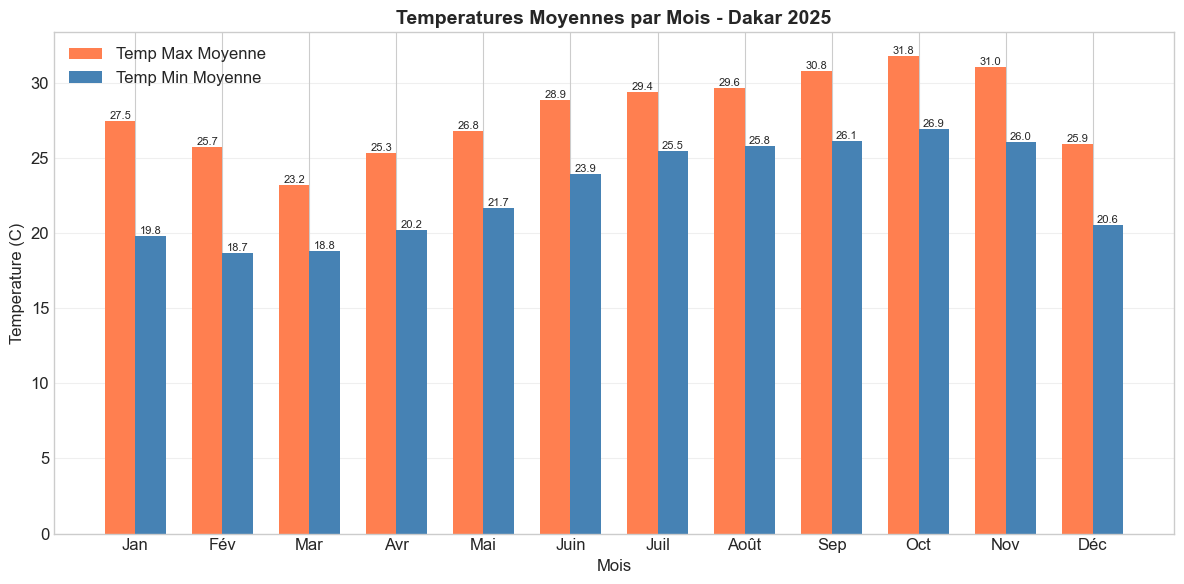

Graphique sauvegarde: data/graphique_temperatures.png

GRAPHIQUE 2: Jours de pluie par mois


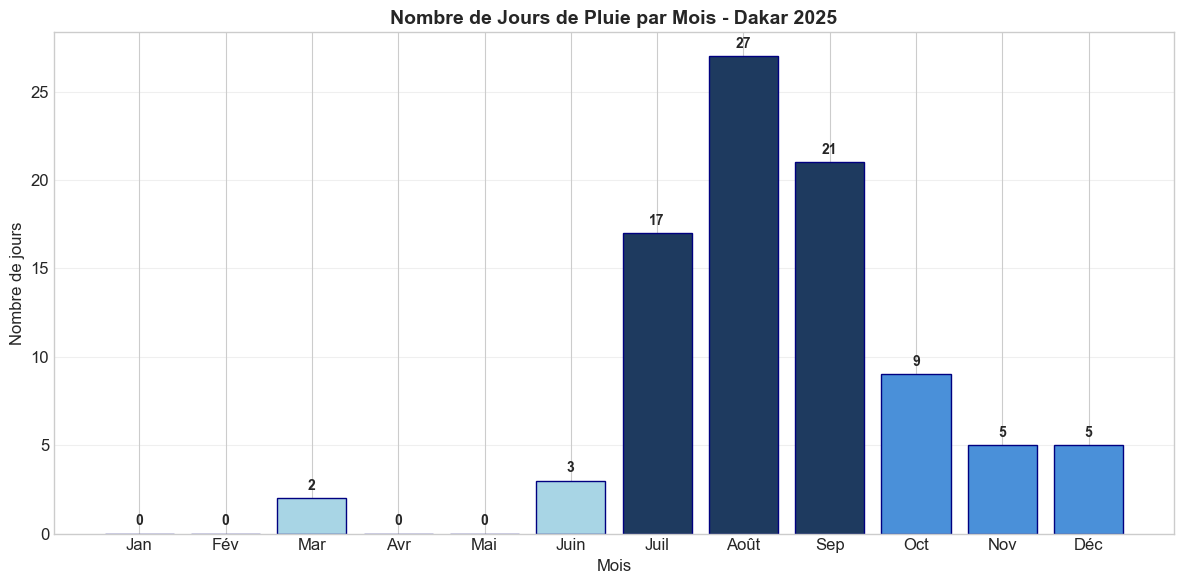

Graphique sauvegarde: data/graphique_pluie.png

GRAPHIQUE 3: Evolution des temperatures


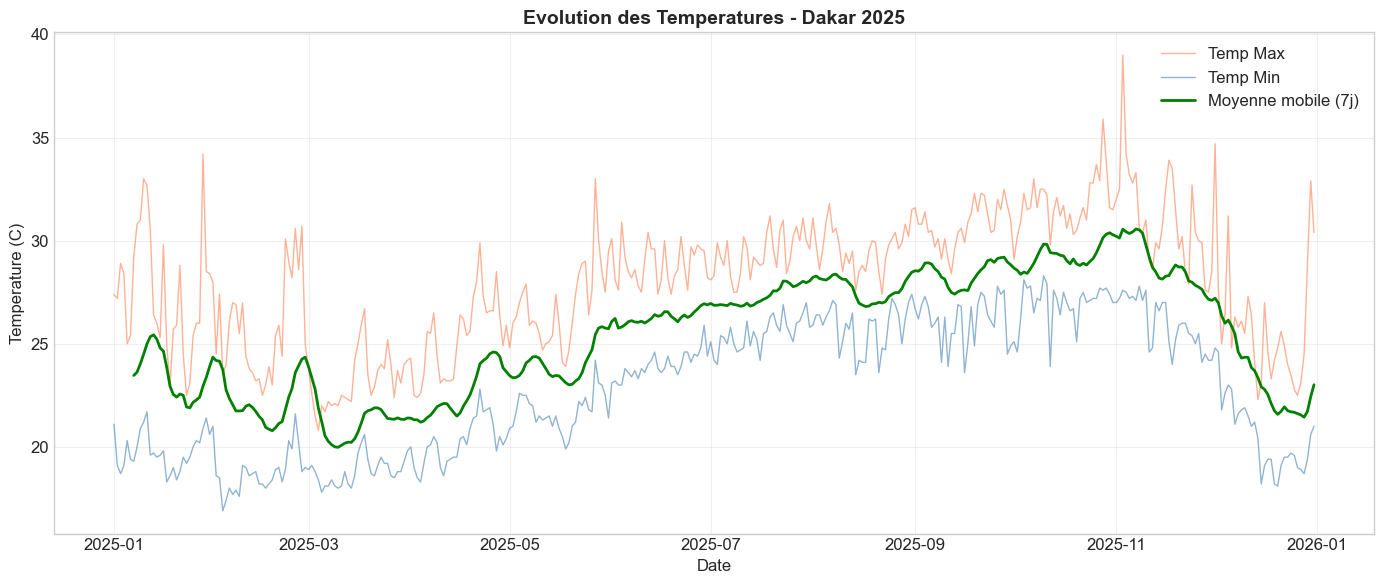

Graphique sauvegarde: data/graphique_evolution.png

         PROJET METEO DAKAR 2025 - TERMINE !

Fichiers generes:
  - data/meteo_dakar_2025_raw.json (donnees brutes)
  - data/meteo_dakar_2025_clean.csv (donnees nettoyees)
  - data/graphique_temperatures.png
  - data/graphique_pluie.png  
  - data/graphique_evolution.png

Base de donnees:
  - PostgreSQL sur Render.com
  - Table: meteo_dakar
  - 365 lignes inserees

Requetes SQL realisees:
  1. Temperature moyenne par mois
  2. Nombre de jours de pluie par mois
  3. Top 10 des jours les plus chauds



In [40]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt

DB_CONFIG = {
    "host": "dpg-d6t7gendiees73cpecqg-a.oregon-postgres.render.com",
    "port": "5432",
    "database": "meteo_dakar_db_512u_d10s",
    "user": "meteo_dakar_db_512u_d10s_user",
    "password": "w0FF5f1kxgZM6ujaDdEQRza9C822ShOA",
    "sslmode" : "require"
}

conn = psycopg2.connect(**DB_CONFIG)
cur = conn.cursor()

print("=" * 50)
print("REQUÊTE 1: Température moyenne par mois")
print("=" * 50)

cur.execute("""
    SELECT mois,
           ROUND(AVG(temp_max)::numeric, 2) as temp_max_moy,
           ROUND(AVG(temp_min)::numeric, 2) as temp_min_moy,
           ROUND(AVG((temp_max + temp_min) / 2)::numeric, 2) as temp_moy
    FROM meteo_dakar
    GROUP BY mois
    ORDER BY mois;
""")
result1 = cur.fetchall()
df_temp = pd.DataFrame(result1, columns=["mois", "temp_max_moy", "temp_min_moy", "temp_moy"])
print(df_temp)

print("\n" + "=" * 50)
print("REQUÊTE 2: Nombre de jours de pluie par mois")
print("=" * 50)

cur.execute("""
    SELECT mois, 
           SUM(pluie_ind) as jours_pluie,
           ROUND(SUM(pluie_mm)::numeric, 2) as total_pluie_mm
    FROM meteo_dakar
    GROUP BY mois
    ORDER BY mois;
""")
result2 = cur.fetchall()
df_pluie = pd.DataFrame(result2, columns=["mois", "jours_pluie", "total_pluie_mm"])
print(df_pluie)

print("\n" + "=" * 50)
print("REQUÊTE 3: Top 10 des jours les plus chauds")
print("=" * 50)

cur.execute("""
    SELECT date, temp_max, temp_min, diff_temp
    FROM meteo_dakar
    ORDER BY temp_max DESC
    LIMIT 10;
""")
result3 = cur.fetchall()
df_top = pd.DataFrame(result3, columns=["date", "temp_max", "temp_min", "diff_temp"])
print(df_top)

cur.close()
conn.close()


mois_noms = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 
             'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

print("\n" + "=" * 50)
print("GRAPHIQUE 1: Températures par mois")
print("=" * 50)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_temp))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_temp["temp_max_moy"], 
               width, label='Temp Max Moyenne', color='coral')
bars2 = ax.bar([i + width/2 for i in x], df_temp["temp_min_moy"], 
               width, label='Temp Min Moyenne', color='steelblue')

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Mois', fontsize=12)
ax.set_ylabel('Temperature (C)', fontsize=12)
ax.set_title('Temperatures Moyennes par Mois - Dakar 2025', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(mois_noms)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("data/graphique_temperatures.png", dpi=150)
plt.show()
print("Graphique sauvegarde: data/graphique_temperatures.png")

print("\n" + "=" * 50)
print("GRAPHIQUE 2: Jours de pluie par mois")
print("=" * 50)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#a8d5e5' if x < 5 else '#4a90d9' if x < 10 else '#1e3a5f' 
          for x in df_pluie["jours_pluie"]]

bars = ax.bar(mois_noms, df_pluie["jours_pluie"], color=colors, edgecolor='navy')

for bar, val in zip(bars, df_pluie["jours_pluie"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
            f'{int(val)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Mois', fontsize=12)
ax.set_ylabel('Nombre de jours', fontsize=12)
ax.set_title('Nombre de Jours de Pluie par Mois - Dakar 2025', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("data/graphique_pluie.png", dpi=150)
plt.show()
print("Graphique sauvegarde: data/graphique_pluie.png")

print("\n" + "=" * 50)
print("GRAPHIQUE 3: Evolution des temperatures")
print("=" * 50)

df_full = pd.read_csv("data/meteo_dakar_2025_clean.csv")
df_full["date"] = pd.to_datetime(df_full["date"])

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_full["date"], df_full["temp_max"], label="Temp Max", color="coral", alpha=0.6, linewidth=1)
ax.plot(df_full["date"], df_full["temp_min"], label="Temp Min", color="steelblue", alpha=0.6, linewidth=1)

df_full["temp_moy"] = (df_full["temp_max"] + df_full["temp_min"]) / 2
df_full["temp_rolling"] = df_full["temp_moy"].rolling(window=7).mean()
ax.plot(df_full["date"], df_full["temp_rolling"], label="Moyenne mobile (7j)", 
        color="green", linewidth=2)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Temperature (C)', fontsize=12)
ax.set_title('Evolution des Temperatures - Dakar 2025', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("data/graphique_evolution.png", dpi=150)
plt.show()
print("Graphique sauvegarde: data/graphique_evolution.png")

print("\n" + "=" * 60)
print("         PROJET METEO DAKAR 2025 - TERMINE !")
print("=" * 60)
print("""
Fichiers generes:
  - data/meteo_dakar_2025_raw.json (donnees brutes)
  - data/meteo_dakar_2025_clean.csv (donnees nettoyees)
  - data/graphique_temperatures.png
  - data/graphique_pluie.png  
  - data/graphique_evolution.png

Base de donnees:
  - PostgreSQL sur Render.com
  - Table: meteo_dakar
  - 365 lignes inserees

Requetes SQL realisees:
  1. Temperature moyenne par mois
  2. Nombre de jours de pluie par mois
  3. Top 10 des jours les plus chauds
""")